In [1]:
# ===== Cell 1: setup & config =====
import os, json, re, collections, math, random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T

# Repro
SEED = 1337
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- paths (adapt if needed) ----
ROOT = "PartImageNet_Seg/PartImageNet"                 # folder containing 'annotations' and 'images'
TRAIN_ANN = "annotations/train/train.json"
VAL_ANN   = "annotations/val/val.json"
TEST_ANN  = "annotations/test/test.json"

TRAIN_IMG_ROOT = "images/train"
VAL_IMG_ROOT   = "images/val"
TEST_IMG_ROOT  = "images/test"

# ---- AlexNet / ImageNet transforms ----
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Minimum crop size in pixels (width/height); use 12+ to skip tiny boxes
MIN_SIZE = 12

print("Device:", DEVICE)


Device: cuda


In [2]:
# ===== Cell 2: dataset helpers (robust key lookup; bbox/seg -> crop; path resolution) =====

FILE_KEYS  = ["file_name","fileName","path","image","name"]
CATID_KEYS = ["category_id","categoryId","object_category_id","obj_cat"]
BBOX_KEYS  = ["bbox","bBox","box"]
SEG_KEYS   = ["segmentation","seg","polygon"]

def _find_any(d, keys):
    for k in keys:
        if k in d: return d[k]
    return None

def _derive_part_from_category_name(cat_name: str) -> str:
    if not cat_name: return "misc"
    s = re.sub(r"[-_]+", " ", str(cat_name).strip().lower())
    toks = s.split()
    return toks[-1] if toks else "misc"   # e.g., 'Biped Body' -> 'body'

def _box_from_poly(poly):
    xs = poly[0::2]; ys = poly[1::2]
    return [float(min(xs)), float(min(ys)), float(max(xs)-min(xs)), float(max(ys)-min(ys))]

def pil_crop_from_ann(img: Image.Image, ann: dict):
    bx = _find_any(ann, BBOX_KEYS)
    if bx is None:
        seg = _find_any(ann, SEG_KEYS)
        if seg and isinstance(seg, list) and len(seg) > 0:
            poly = seg[0] if isinstance(seg[0], list) else seg
            if isinstance(poly, dict) and "counts" in poly:
                # RLE mask not supported here — fallback to full image (skip via size below)
                return None
            bx = _box_from_poly(poly)
        else:
            return None
    if isinstance(bx, dict):
        x,y,w,h = float(bx.get("x",0)), float(bx.get("y",0)), float(bx.get("width",0)), float(bx.get("height",0))
    else:
        x,y,w,h = map(float, bx)
    x0, y0 = int(max(0, x)), int(max(0, y))
    x1, y1 = int(min(img.width, x+w)), int(min(img.height, y+h))
    if x1 <= x0 or y1 <= y0: return None
    return img.crop((x0, y0, x1, y1))

def resolve_path(root: str, images_root: str, fn: str) -> Optional[str]:
    # Try several plausible locations
    base = Path(root)
    imroot = base / images_root if images_root else base
    candidates = [
        imroot / fn,                          # images/train/nXXXX.JPEG
        base / "images" / fn,                 # images/nXXXX.JPEG
        base / "JPEGImages" / fn,             # JPEGImages/nXXXX.JPEG
        base / fn,                            # direct
        base.parent / fn,                     # parent
    ]
    for p in candidates:
        if p.exists(): return str(p)
    return None


In [3]:
# ===== Cell 3: global clusters + dataset definition =====
import collections

def build_global_clusters(root: str, ann_paths: List[str]) -> Dict[str, List[str]]:
    """part_token -> sorted list of ORIGINAL category names (global vocab across splits)."""
    by_part = collections.defaultdict(set)
    for rel in ann_paths:
        p = os.path.join(root, rel)
        if not os.path.exists(p): 
            print("[warn] missing ann:", p)
            continue
        J = json.load(open(p, "r"))
        for c in J.get("categories", []):
            nm = str(c.get("name","")).strip()
            if not nm: continue
            by_part[_derive_part_from_category_name(nm)].add(nm)
    return {part: sorted(names) for part, names in by_part.items()}

GLOBAL_CLUSTERS = build_global_clusters(ROOT, [TRAIN_ANN, VAL_ANN, TEST_ANN])
CANONICAL_PARTS = sorted(GLOBAL_CLUSTERS.keys())
PART_TO_IDX = {p:i for i,p in enumerate(CANONICAL_PARTS)}
print("Discovered parts:", CANONICAL_PARTS)

class PartExample:
    __slots__ = ("img_path","part_canonical","cluster_name","bbox_or_seg_ann","image_id")
    def __init__(self, img_path: str, part_canonical: str, cluster_name: str, bbox_or_seg_ann: dict, image_id: int):
        self.img_path = img_path
        self.part_canonical = part_canonical   # e.g., 'body'
        self.cluster_name = cluster_name       # original category name, e.g., 'Biped Body'
        self.bbox_or_seg_ann = bbox_or_seg_ann
        self.image_id = image_id

class PartCropDataset2(Dataset):
    def __init__(self, root: str, json_path: str, images_root: str,
                 transform=None, min_size: int = 12,
                 global_clusters: Optional[Dict[str, List[str]]] = None):
        super().__init__()
        self.root, self.images_root = root, images_root
        self.transform = transform
        self.min_size = min_size
        self.global_clusters = global_clusters or GLOBAL_CLUSTERS

        J = json.load(open(os.path.join(root, json_path), "r"))
        self.cat_map = {int(c["id"]): c for c in J.get("categories", []) if "id" in c}

        # image_id -> resolved file path
        self.image_map = {}
        for im in J.get("images", []):
            fn = _find_any(im, FILE_KEYS)
            if not fn: continue
            im_id = im.get("id", im.get("image_id", len(self.image_map)))
            full = resolve_path(root, images_root, fn)
            if full: self.image_map[im_id] = full

        # Build items list (skip bad entries)
        items = []
        miss_path = miss_cat = tiny_box = 0
        for a in J.get("annotations", []):
            img_id = a.get("image_id", a.get("id"))
            full = self.image_map.get(img_id)
            if not full or not os.path.exists(full):
                miss_path += 1; 
                continue

            cid = _find_any(a, CATID_KEYS)
            cat = self.cat_map.get(int(cid), {}) if cid is not None else {}
            cat_name = cat.get("name"); supercat = cat.get("supercategory")
            if not cat_name and not supercat:
                miss_cat += 1; 
                continue

            # quickly test crop size to filter tiny/invalid
            try:
                with Image.open(full) as img:
                    img = img.convert("RGB")
                    crop = pil_crop_from_ann(img, a)
            except Exception:
                crop = None
            if crop is None or crop.width < self.min_size or crop.height < self.min_size:
                tiny_box += 1; 
                continue

            part = _derive_part_from_category_name(cat_name or "")
            cluster_name = str(cat_name or supercat or "unknown")
            items.append(PartExample(full, part, cluster_name, a, img_id))

        self.items: List[PartExample] = items

        # Build detector_clusters with the provided global order
        self.detector_clusters: Dict[str, Dict[str,int]] = {
            p: {name:i for i, name in enumerate(self.global_clusters.get(p, []))}
            for p in CANONICAL_PARTS
        }

        # Count OOV (cluster names present in items but not in global map)
        self.oov_counts = {}
        for it in self.items:
            if it.cluster_name not in self.detector_clusters.get(it.part_canonical, {}):
                self.oov_counts[it.part_canonical] = self.oov_counts.get(it.part_canonical, 0) + 1

        print(f"[PartCropDataset2] images={len(self.image_map)} items={len(self.items)} "
              f"miss_path={miss_path} miss_cat={miss_cat} tiny/invalid={tiny_box}")
        if self.oov_counts:
            print("OOV cluster labels found (ignored at __getitem__):", self.oov_counts)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it.img_path).convert("RGB")
        crop = pil_crop_from_ann(img, it.bbox_or_seg_ann)
        if crop is None:
            # fallback black chip (should be rare); will be dropped by transform
            crop = Image.new("RGB", (224,224), (0,0,0))
        x = self.transform(crop) if self.transform else T.ToTensor()(crop)
        det_idx = PART_TO_IDX.get(it.part_canonical, -1)             # which detector (canonical part)
        # cluster index within canonical part (may be -1 if OOV)
        cluster_idx = self.detector_clusters.get(it.part_canonical, {}).get(it.cluster_name, -1)
        return x, det_idx, cluster_idx, it.image_id


Discovered parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']


In [4]:
# ===== Cell 4: instantiate datasets =====
ds_tr = PartCropDataset2(ROOT, TRAIN_ANN, TRAIN_IMG_ROOT, transform=train_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
ds_val = PartCropDataset2(ROOT, VAL_ANN,   VAL_IMG_ROOT,   transform=eval_tf,   min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)

print("num part-crops (train):", len(ds_tr))
print("num part-crops (val):  ", len(ds_val))
print("parts:", CANONICAL_PARTS)
for p in CANONICAL_PARTS:
    print(f"{p:12s} -> {len(ds_tr.detector_clusters[p])} clusters in train")


[PartCropDataset2] images=20466 items=90849 miss_path=0 miss_cat=0 tiny/invalid=4210
[PartCropDataset2] images=1206 items=5334 miss_path=0 miss_cat=0 tiny/invalid=292
num part-crops (train): 90849
num part-crops (val):   5334
parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']
body         -> 11 clusters in train
engine       -> 1 clusters in train
fin          -> 1 clusters in train
foot         -> 4 clusters in train
hand         -> 1 clusters in train
head         -> 8 clusters in train
mirror       -> 1 clusters in train
mouth        -> 1 clusters in train
sail         -> 1 clusters in train
seat         -> 1 clusters in train
tail         -> 6 clusters in train
tier         -> 2 clusters in train
wing         -> 2 clusters in train


In [5]:
# ===== Cell 5: binary (pos/neg) view per part =====
class BinaryPartDataset(Dataset):
    """Wraps PartCropDataset2 -> returns (x, y_binary, image_id) for a single canonical part.
       y_binary: 1 if item.part_canonical == target_part else 0.
       Optionally downsample negatives to keep neg:pos ~ max_neg_per_pos.
    """
    def __init__(self, base: PartCropDataset2, target_part: str, transform=None, max_neg_per_pos: float = 3.0):
        self.base = base
        self.part = target_part
        self.transform = transform or base.transform
        self.pos_ids = [i for i, it in enumerate(base.items) if it.part_canonical == target_part]
        self.neg_ids = [i for i, it in enumerate(base.items) if it.part_canonical != target_part]
        if max_neg_per_pos is not None and math.isfinite(max_neg_per_pos):
            # simple downsample to keep manageable class balance
            max_neg = int(max_neg_per_pos * max(1, len(self.pos_ids)))
            if len(self.neg_ids) > max_neg:
                random.shuffle(self.neg_ids)
                self.neg_ids = self.neg_ids[:max_neg]
        self.ids = self.pos_ids + self.neg_ids
        self.labels = [1]*len(self.pos_ids) + [0]*len(self.neg_ids)
        print(f"[BinaryPartDataset] part={target_part}  pos={len(self.pos_ids)} neg={len(self.neg_ids)} "
              f"(ratio={len(self.neg_ids)/max(1,len(self.pos_ids)):.2f})")

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        j = self.ids[i]; y = self.labels[i]
        x, _, _, imid = self.base[j]
        # ensure identical transform
        if self.transform and x.ndim == 3 and x.shape[-1] in (3,):
            # already transformed by base; nothing extra
            pass
        return x, int(y), imid

def make_balanced_loader(ds: BinaryPartDataset, batch_size: int = 128, num_workers: int = 8, pin_memory: bool = True):
    # Build per-item weights to balance classes inside the dataset
    counts = collections.Counter(ds.labels)
    w = {c: 1.0/max(1, n) for c, n in counts.items()}
    weights = torch.tensor([w[int(y)] for y in ds.labels], dtype=torch.float)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=pin_memory, drop_last=False)


In [6]:
# ===== Cell 6: binary AlexNet model + training loop =====
from part_detector_refactor import PartDetectorTiny  # reuses same AlexNet backbone & MLP head

class BinaryAlexNet(nn.Module):
    def __init__(self, emb_dim: int = 128, backbone_trainable: bool = True, weights: Optional[str] = "imagenet"):
        super().__init__()
        # 2-way classifier (pos/neg)
        self.net = PartDetectorTiny(emb_dim=emb_dim, num_classes=2, backbone="alexnet", backbone_trainable=backbone_trainable, weights=weights)
    def forward(self, x):
        _, logits = self.net(x)
        return logits

@torch.no_grad()
def binary_acc(logits: torch.Tensor, y: torch.Tensor) -> float:
    return (logits.argmax(1) == y).float().mean().item()

def train_binary_for_part(part_name: str,
                          ds_train: PartCropDataset2,
                          ds_val: Optional[PartCropDataset2],
                          outdir: str = "alex_binary_ckpts",
                          epochs: int = 20,
                          batch_size: int = 128,
                          lr: float = 3e-4,
                          emb_dim: int = 128,
                          max_neg_per_pos: float = 3.0,
                          use_amp: bool = True,
                          channels_last: bool = True,
                          use_tf32: bool = True,
                          num_workers: int = 8):
    os.makedirs(outdir, exist_ok=True)

    # Datasets / loaders
    tr_bin = BinaryPartDataset(ds_train, part_name, transform=ds_train.transform, max_neg_per_pos=max_neg_per_pos)
    vl_bin = BinaryPartDataset(ds_val, part_name, transform=ds_val.transform, max_neg_per_pos=max_neg_per_pos) if ds_val is not None else None
    dl_tr = make_balanced_loader(tr_bin, batch_size=batch_size, num_workers=num_workers, pin_memory=(DEVICE.type=='cuda'))
    dl_vl = DataLoader(vl_bin, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(DEVICE.type=='cuda')) if vl_bin else None

    # Model
    torch.backends.cuda.matmul.allow_tf32 = bool(use_tf32)
    model = BinaryAlexNet(emb_dim=emb_dim).to(DEVICE)
    if channels_last and DEVICE.type == "cuda":
        try: model = model.to(memory_format=torch.channels_last)
        except Exception: pass
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and DEVICE.type=='cuda'))
    best_va = -1.0; best_path = None

    for ep in range(1, epochs+1):
        # ---- train ----
        model.train()
        tr_loss = tr_acc = nbt = 0
        for xb, yb, _ in dl_tr:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True).long()
            if channels_last and xb.ndim == 4 and DEVICE.type=='cuda':
                try: xb = xb.to(memory_format=torch.channels_last)
                except Exception: pass
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tr_loss += float(loss.item()); tr_acc += binary_acc(logits, yb); nbt += 1
        tr_loss /= max(1, nbt); tr_acc /= max(1, nbt)

        # ---- val ----
        va_loss = va_acc = nvb = 0
        if dl_vl is not None:
            model.eval()
            with torch.no_grad():
                for xb, yb, _ in dl_vl:
                    xb = xb.to(DEVICE, non_blocking=True)
                    yb = yb.to(DEVICE, non_blocking=True).long()
                    if channels_last and xb.ndim == 4 and DEVICE.type=='cuda':
                        try: xb = xb.to(memory_format=torch.channels_last)
                        except Exception: pass
                    logits = model(xb)
                    loss = F.cross_entropy(logits, yb)
                    va_loss += float(loss.item()); va_acc += binary_acc(logits, yb); nvb += 1
            va_loss /= max(1, nvb); va_acc /= max(1, nvb)
            sch.step(va_loss)
        print(f"[{part_name}] ep {ep:02d}/{epochs}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.3f}  lr={opt.param_groups[0]['lr']:.2e}")

        if va_acc > best_va:
            best_va = va_acc
            best_path = os.path.join(outdir, f"{part_name}_best.pt")
            torch.save({"part": part_name, "state_dict": model.state_dict(), "emb_dim": emb_dim}, best_path)

    print(f"[{part_name}] best val_acc={best_va:.3f}  ckpt={best_path}")
    return best_path, best_va


In [7]:
# ===== Cell 7: train all parts (skip those with no positives) =====
def train_all_binary_parts(ds_train: PartCropDataset2, ds_val: PartCropDataset2,
                           parts: Optional[List[str]] = None,
                           **kwargs):
    parts = parts or CANONICAL_PARTS
    results = {}
    for p in parts:
        # check if we have positives in train/val
        n_pos_tr = sum(1 for it in ds_train.items if it.part_canonical == p)
        n_pos_vl = sum(1 for it in ds_val.items if it.part_canonical == p)
        if n_pos_tr == 0:
            print(f"[skip] part={p}: no positives in train")
            continue
        if n_pos_vl == 0:
            print(f"[warn] part={p}: no positives in val; will still train & report train metrics only")
        print("-"*80)
        print(f"Training binary detector for part: {p}  (train_pos={n_pos_tr}  val_pos={n_pos_vl})")
        ckpt, acc = train_binary_for_part(p, ds_train, ds_val, **kwargs)
        results[p] = {"ckpt": ckpt, "best_val_acc": float(acc)}
    return results

# Example call (uncomment to run):
# results = train_all_binary_parts(ds_tr, ds_val, epochs=20, batch_size=128, lr=3e-4, emb_dim=128, max_neg_per_pos=3.0)
# print(results)


In [8]:
results = train_all_binary_parts(ds_tr, ds_val, epochs=20, batch_size=128, lr=3e-4, emb_dim=128, max_neg_per_pos=3.0)

--------------------------------------------------------------------------------
Training binary detector for part: body  (train_pos=23903  val_pos=1439)
[BinaryPartDataset] part=body  pos=23903 neg=66946 (ratio=2.80)
[BinaryPartDataset] part=body  pos=1439 neg=3895 (ratio=2.71)


/tmp/ipykernel_131214/3418951382.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and DEVICE.type=='cuda'))
/tmp/ipykernel_131214/3418951382.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


[body] ep 01/20  tr_loss=0.4894 tr_acc=0.763  val_loss=0.4805 val_acc=0.791  lr=3.00e-04
[body] ep 02/20  tr_loss=0.4376 tr_acc=0.793  val_loss=0.4938 val_acc=0.776  lr=3.00e-04
[body] ep 03/20  tr_loss=0.4125 tr_acc=0.807  val_loss=0.4605 val_acc=0.791  lr=3.00e-04
[body] ep 04/20  tr_loss=0.3918 tr_acc=0.818  val_loss=0.4496 val_acc=0.798  lr=3.00e-04
[body] ep 05/20  tr_loss=0.3777 tr_acc=0.827  val_loss=0.4515 val_acc=0.790  lr=3.00e-04
[body] ep 06/20  tr_loss=0.3587 tr_acc=0.835  val_loss=0.4506 val_acc=0.797  lr=3.00e-04
[body] ep 07/20  tr_loss=0.3393 tr_acc=0.848  val_loss=0.4347 val_acc=0.802  lr=3.00e-04
[body] ep 08/20  tr_loss=0.3298 tr_acc=0.853  val_loss=0.4165 val_acc=0.822  lr=3.00e-04
[body] ep 09/20  tr_loss=0.3098 tr_acc=0.863  val_loss=0.4354 val_acc=0.814  lr=3.00e-04
[body] ep 10/20  tr_loss=0.2958 tr_acc=0.869  val_loss=0.5032 val_acc=0.792  lr=3.00e-04
[body] ep 11/20  tr_loss=0.2852 tr_acc=0.875  val_loss=0.5014 val_acc=0.781  lr=1.50e-04
[body] ep 12/20  tr_l

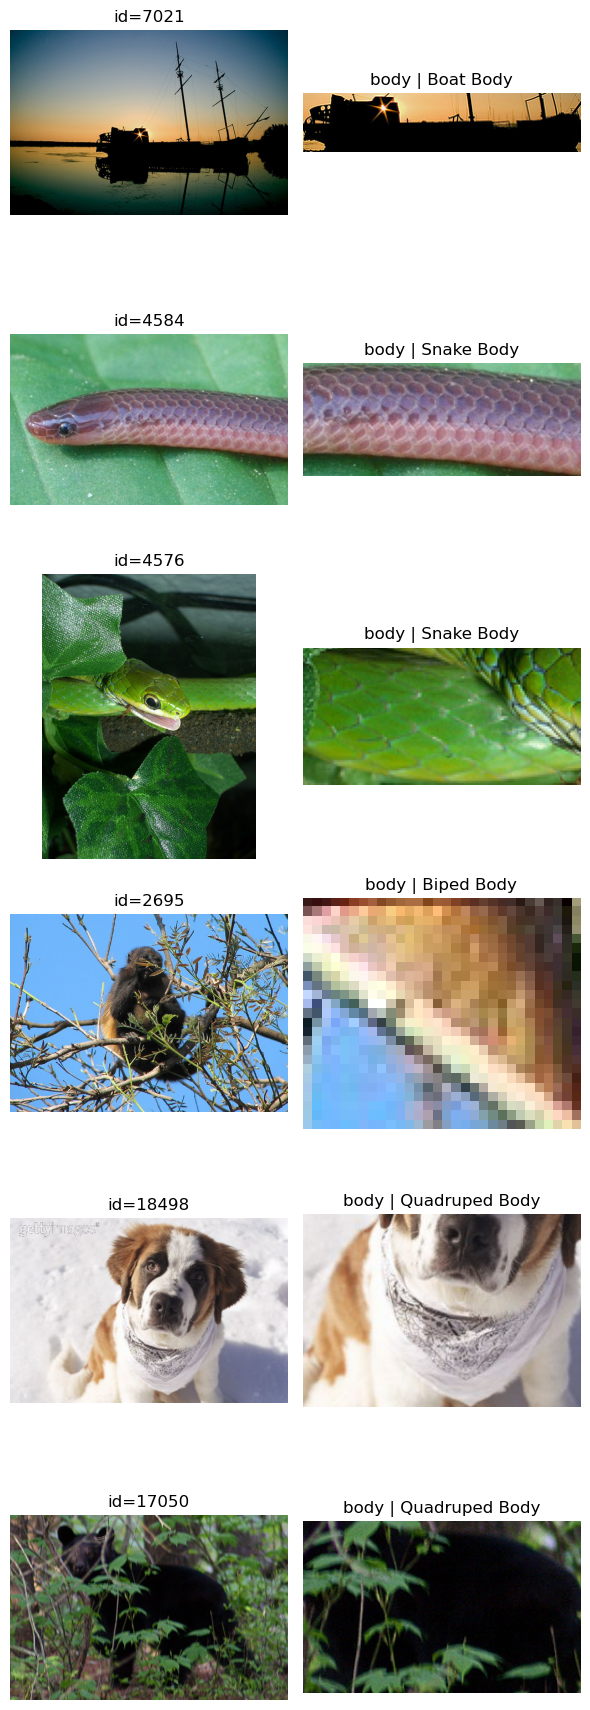

In [9]:
# ===== Cell 8 (optional): inspect a few random crops per part =====
import matplotlib.pyplot as plt
import numpy as np

def show_random_crops(base: PartCropDataset2, part: str, k: int = 8):
    idxs = [i for i, it in enumerate(base.items) if it.part_canonical == part]
    random.shuffle(idxs)
    idxs = idxs[:k]
    fig, axes = plt.subplots(k, 2, figsize=(6, 3*k))
    for r, i in enumerate(idxs):
        it = base.items[i]
        img = Image.open(it.img_path).convert("RGB")
        crop = pil_crop_from_ann(img, it.bbox_or_seg_ann)
        axes[r,0].imshow(img); axes[r,0].axis('off'); axes[r,0].set_title(f"id={it.image_id}")
        if crop is not None:
            axes[r,1].imshow(crop); axes[r,1].axis('off'); axes[r,1].set_title(f"{it.part_canonical} | {it.cluster_name}")
        else:
            axes[r,1].axis('off'); axes[r,1].set_title("bad crop")
    plt.tight_layout(); plt.show()

# Example:
show_random_crops(ds_tr, "body", k=6)


In [10]:
ckpt="alex_binary_ckpts/body_best.pt"

In [11]:
# ===== Cell A: restore binary AlexNet per-part detector from checkpoint =====
import os, json, math, random
from pathlib import Path
from typing import Optional, List, Dict, Tuple

import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from part_detector_refactor import PartDetectorTiny  # same module used during training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- IMPORTANT: use the exact path you asked for ----
ckpt_path = "alex_binary_ckpts/body_best.pt"   # e.g., for the 'body' detector

# Minimal wrapper that mirrors the training-time binary AlexNet
class BinaryAlexNet(nn.Module):
    def __init__(self, emb_dim: int = 128, backbone_trainable: bool = False, weights: Optional[str] = None):
        super().__init__()
        # 2-way classifier (pos/neg)
        self.net = PartDetectorTiny(
            emb_dim=emb_dim,
            num_classes=2,
            backbone="alexnet",
            backbone_trainable=backbone_trainable,
            weights=weights,           # None or "imagenet" (weights do not matter after loading checkpoint)
        )
    def forward(self, x):
        _, logits = self.net(x)        # PartDetectorTiny returns (emb, logits)
        return logits

@torch.no_grad()
def binary_acc(logits: torch.Tensor, y: torch.Tensor) -> float:
    return (logits.argmax(1) == y).float().mean().item()

# Load checkpoint and build the model with the same embedding size
ckpt = torch.load(ckpt_path, map_location=DEVICE)
emb_dim = int(ckpt.get("emb_dim", 128))
det_part = str(ckpt.get("part", "body")).lower()    # e.g., "body"

model = BinaryAlexNet(emb_dim=emb_dim, backbone_trainable=False, weights=None).to(DEVICE)
model.load_state_dict(ckpt["state_dict"], strict=True)
model.eval()

print(f"Restored binary detector for part='{det_part}' (emb_dim={emb_dim}) from: {ckpt_path}")


Restored binary detector for part='body' (emb_dim=128) from: alex_binary_ckpts/body_best.pt


In [12]:
# ===== Cell B: evaluate on val with balanced pos:neg =====

# We rely on ds_val defined earlier:
# ds_val = PartCropDataset2(ROOT, VAL_ANN, VAL_IMG_ROOT, transform=eval_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
assert 'ds_val' in globals(), "Please run the earlier cell that creates ds_val = PartCropDataset2(...)."

# Map canonical part -> detector index (created earlier)
assert 'PART_TO_IDX' in globals() and det_part in PART_TO_IDX
det_idx_pos = PART_TO_IDX[det_part]

# Collect indices of positives and negatives in val
val_pos = [i for i, it in enumerate(ds_val.items) if it.part_canonical == det_part]
val_neg = [i for i, it in enumerate(ds_val.items) if it.part_canonical != det_part]

print(f"[val set] positives for '{det_part}': {len(val_pos)}   negatives: {len(val_neg)}   total: {len(ds_val)}")

# Balanced evaluation parameters (match training spirit)
neg_per_pos = 3.0   # 1:1; set to 3.0 to mirror max_neg_per_pos during training
batch_size  = 128

@torch.no_grad()
def eval_balanced_val(model, neg_per_pos: float = 1.0, batch_size: int = 128):
    rng = random.Random(1337)
    # draw negatives for each positive
    n_pos = len(val_pos)
    n_neg = min(len(val_neg), int(math.floor(n_pos * neg_per_pos)))
    neg_sample = rng.sample(val_neg, n_neg) if n_neg > 0 else []

    # Build (x, y) lists; y=1 for positives, 0 for negatives
    idxs = val_pos + neg_sample
    labels = [1]*len(val_pos) + [0]*len(neg_sample)

    # shuffle pairs in unison
    order = list(range(len(idxs)))
    rng.shuffle(order)
    idxs   = [idxs[i] for i in order]
    labels = [labels[i] for i in order]

    # Iterate in mini-batches (no DataLoader to match your notebook style)
    all_logits, all_y = [], []
    for i in range(0, len(idxs), batch_size):
        chunk = idxs[i:i+batch_size]
        xs, ys = [], []
        for j in chunk:
            x, det_idx, cl_idx, image_id = ds_val[j]         # x already normalized by eval_tf
            y = 1 if det_idx == det_idx_pos else 0
            xs.append(x)
            ys.append(y)
        xb = torch.stack(xs).to(DEVICE, non_blocking=True)
        yb = torch.tensor(ys, dtype=torch.long, device=DEVICE)
        logits = model(xb)
        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    ytrue  = torch.cat(all_y, dim=0)
    acc    = binary_acc(logits, ytrue)

    # Optional: richer metrics if sklearn is available
    try:
        from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
        probs = logits.softmax(1)[:,1].numpy()
        print(classification_report(ytrue.numpy(), logits.argmax(1).numpy(),
                                    target_names=["neg","pos"], digits=4))
        try:
            print("AUROC:", roc_auc_score(ytrue.numpy(), probs))
        except Exception:
            pass
        print("Confusion matrix:\n", confusion_matrix(ytrue.numpy(), logits.argmax(1).numpy()))
    except Exception:
        pass

    print(f"[balanced VAL] acc={acc:.3f}  (neg_per_pos={neg_per_pos})")
    return acc

val_acc_bal = eval_balanced_val(model, neg_per_pos=neg_per_pos, batch_size=batch_size)
print(f"Final balanced validation accuracy for '{det_part}': {val_acc_bal:.3f}")


[val set] positives for 'body': 1439   negatives: 3895   total: 5334
              precision    recall  f1-score   support

         neg     0.8739    0.8896    0.8817      3895
         pos     0.6859    0.6525    0.6688      1439

    accuracy                         0.8256      5334
   macro avg     0.7799    0.7711    0.7752      5334
weighted avg     0.8232    0.8256    0.8242      5334

AUROC: 0.8623469978527736
Confusion matrix:
 [[3465  430]
 [ 500  939]]
[balanced VAL] acc=0.826  (neg_per_pos=3.0)
Final balanced validation accuracy for 'body': 0.826


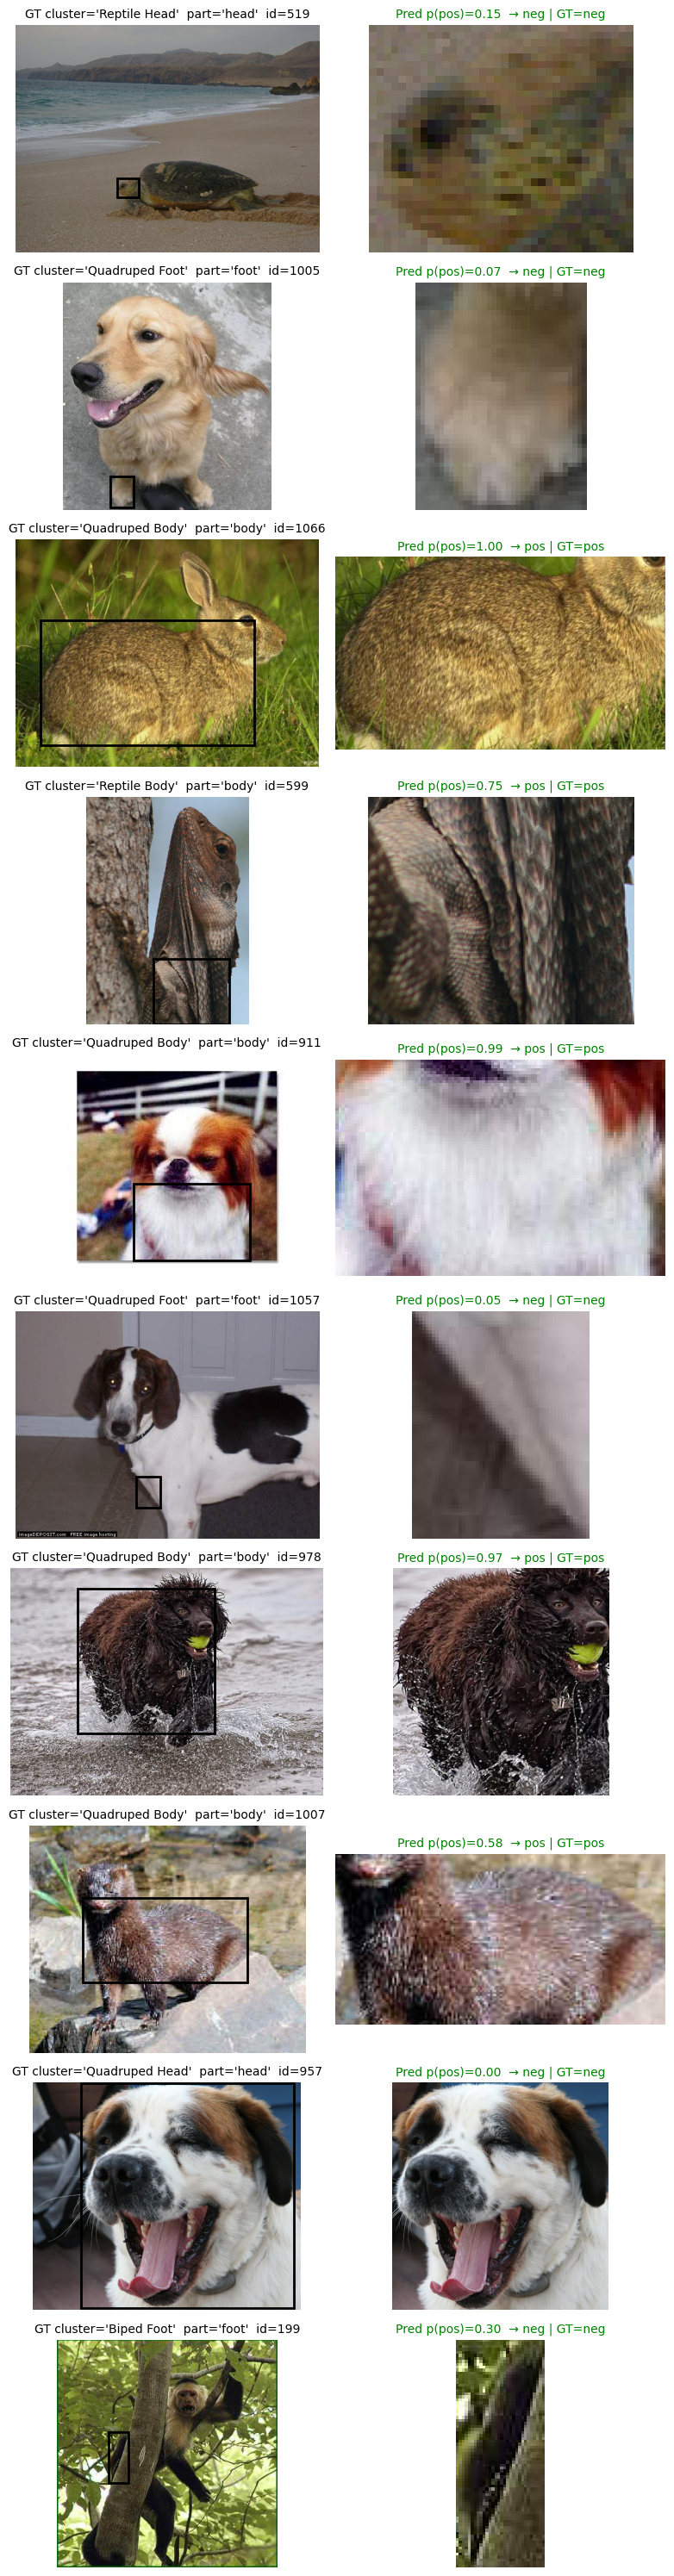

In [13]:
# ===== Cell C: visualize predicted vs. ground-truth on a few validation examples =====

def _ann_to_xyxy(ann: dict, img_size: Tuple[int,int]) -> Optional[Tuple[int,int,int,int]]:
    """Derive an (x0,y0,x1,y1) box from the 'bbox' or a polygon in 'segmentation'."""
    bx = _find_any(ann, BBOX_KEYS)
    if bx is None:
        seg = _find_any(ann, SEG_KEYS)
        if seg and isinstance(seg, list) and len(seg) > 0:
            poly = seg[0] if isinstance(seg[0], list) else seg
            if isinstance(poly, dict) and "counts" in poly:
                return None
            # reuse the same bounding logic as pil_crop_from_ann
            x, y, w, h = _box_from_poly(poly)
        else:
            return None
    else:
        if isinstance(bx, dict):
            x,y,w,h = float(bx.get("x",0)), float(bx.get("y",0)), float(bx.get("width",0)), float(bx.get("height",0))
        else:
            x,y,w,h = map(float, bx)
    W,H = img_size
    x0, y0 = int(max(0, x)), int(max(0, y))
    x1, y1 = int(min(W, x+w)), int(min(H, y+h))
    if x1 <= x0 or y1 <= y0: 
        return None
    return (x0,y0,x1,y1)

@torch.no_grad()
def visualize_preds_for_part(model, part_name: str, k: int = 12, seed: int = 1337):
    rng = random.Random(seed)
    part_idx = PART_TO_IDX[part_name]
    # Prefer half positives and half negatives for a balanced view
    pos_idxs = [i for i,it in enumerate(ds_val.items) if it.part_canonical == part_name]
    neg_idxs = [i for i,it in enumerate(ds_val.items) if it.part_canonical != part_name]
    if len(pos_idxs) == 0:
        print(f"No positives in val for part='{part_name}'.")
        return
    show_pos = rng.sample(pos_idxs, min(k//2, len(pos_idxs)))
    show_neg = rng.sample(neg_idxs, min(k - len(show_pos), len(neg_idxs)))
    idxs = show_pos + show_neg
    rng.shuffle(idxs)

    n = len(idxs)
    cols = 2
    rows = n
    fig, axes = plt.subplots(rows, cols, figsize=(8, 3*rows))

    for r, i in enumerate(idxs):
        x, det_idx, cl_idx, image_id = ds_val[i]
        it = ds_val.items[i]                                # PartExample with img_path and ann
        img = Image.open(it.img_path).convert("RGB")
        ann = it.bbox_or_seg_ann
        chip = pil_crop_from_ann(img, ann)                  # what the model actually sees

        # prediction
        xb = x.unsqueeze(0).to(DEVICE)
        logits = model(xb)
        prob_pos = float(logits.softmax(1)[0,1].item())
        y_true = 1 if det_idx == part_idx else 0
        y_pred = int(prob_pos >= 0.5)

        # left: full image with GT box
        axL = axes[r,0] if rows > 1 else axes[0]
        axL.imshow(img)
        axL.axis('off')

        xyxy = _ann_to_xyxy(ann, (img.width, img.height))
        title_L = f"GT cluster='{it.cluster_name}'  part='{it.part_canonical}'  id={it.image_id}"
        if xyxy is not None:
            draw = ImageDraw.Draw(img)
            # redraw overlay (matplotlib overlays on copy, so we add via rectangle on ax)
            x0,y0,x1,y1 = xyxy
            axL.add_patch(plt.Rectangle((x0,y0), x1-x0, y1-y0, fill=False, linewidth=2))
        axL.set_title(title_L, fontsize=10)

        # right: chip with pred/gt
        axR = axes[r,1] if rows > 1 else axes[1]
        if chip is None:
            chip = Image.new("RGB", (224,224), (0,0,0))
        axR.imshow(chip)
        axR.axis('off')
        axR.set_title(f"Pred p(pos)={prob_pos:.2f}  → {'pos' if y_pred==1 else 'neg'} | GT={'pos' if y_true==1 else 'neg'}",
                      fontsize=10, color=("green" if y_pred==y_true else "red"))

    plt.tight_layout()
    plt.show()

# Visualize a few examples for the detector loaded above
visualize_preds_for_part(model, det_part, k=10)


In [14]:
# ===== Cell 1: discover and load all per-part binary AlexNet detectors =====
import os, json, math, random
from pathlib import Path
from typing import Dict, Tuple, List

import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from part_detector_refactor import PartDetectorTiny  # same module used in training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = "alex_binary_ckpts"  # <- your training code saved ckpts here

class BinaryAlexNet(nn.Module):
    def __init__(self, emb_dim: int = 128):
        super().__init__()
        self.net = PartDetectorTiny(
            emb_dim=emb_dim, num_classes=2,
            backbone="alexnet", backbone_trainable=False, weights=None
        )
    def forward(self, x):
        _, logits = self.net(x)   # logits: [B, 2]  -> (neg, pos)
        return logits

def load_detector(ckpt_path: str) -> Tuple[str, nn.Module, int]:
    """Return (part_name, model, emb_dim)."""
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    part = str(ckpt.get("part", Path(ckpt_path).stem.replace("_best",""))).lower()
    emb  = int(ckpt.get("emb_dim", 128))
    model = BinaryAlexNet(emb_dim=emb).to(DEVICE)
    model.load_state_dict(ckpt["state_dict"], strict=True)
    model.eval()
    return part, model, emb

# Load every *_best.pt
detectors: Dict[str, nn.Module] = {}
for p in sorted(Path(CKPT_DIR).glob("*_best.pt")):
    part, model, emb = load_detector(str(p))
    detectors[part] = model

print(f"Loaded {len(detectors)} detectors:", ", ".join(sorted(detectors.keys())))


Loaded 13 detectors: body, engine, fin, foot, hand, head, mirror, mouth, sail, seat, tail, tier, wing


In [15]:
# ===== Cell 2: make sure ds_val is available (uses your existing variables) =====
if 'ds_val' not in globals():
    ds_val = PartCropDataset2(
        ROOT, VAL_ANN, VAL_IMG_ROOT,
        transform=eval_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS
    )
print("VAL size:", len(ds_val))


VAL size: 5334


In [16]:
# ===== Cell 3: per-detector balanced validation metrics (no DataLoader) =====
import numpy as np

def _balanced_indices_for_part(ds, part_name: str, neg_per_pos: float = 1.0, seed: int = 1337):
    rng = random.Random(seed)
    pos = [i for i,it in enumerate(ds.items) if it.part_canonical == part_name]
    neg = [i for i,it in enumerate(ds.items) if it.part_canonical != part_name]
    n_pos = len(pos)
    n_neg_keep = min(len(neg), int(math.floor(n_pos * neg_per_pos)))
    neg = rng.sample(neg, n_neg_keep) if n_neg_keep > 0 else []
    idxs = pos + neg
    ys   = [1]*len(pos) + [0]*len(neg)
    order = list(range(len(idxs))); rng.shuffle(order)
    idxs = [idxs[k] for k in order]; ys = [ys[k] for k in order]
    return idxs, ys, n_pos, len(neg)

@torch.no_grad()
def _eval_detector_on_indices(model, ds, part_name: str, idxs: List[int], ys: List[int], batch_size: int = 128):
    part_idx = PART_TO_IDX[part_name]
    all_logits, all_y = [], []
    for i in range(0, len(idxs), batch_size):
        chunk = idxs[i:i+batch_size]
        xs, yb = [], []
        for j in chunk:
            x, det_idx, _, _ = ds[j]
            y = 1 if det_idx == part_idx else 0
            xs.append(x); yb.append(y)
        xb = torch.stack(xs).to(DEVICE)
        yb = torch.tensor(yb, dtype=torch.long, device=DEVICE)
        logits = model(xb)             # [B,2]  (neg, pos)
        all_logits.append(logits.cpu()); all_y.append(yb.cpu())
    logits = torch.cat(all_logits, 0).numpy()
    ytrue  = torch.cat(all_y, 0).numpy()
    ypred  = logits.argmax(1)
    # metrics
    tp = int(((ypred == 1) & (ytrue == 1)).sum())
    tn = int(((ypred == 0) & (ytrue == 0)).sum())
    fp = int(((ypred == 1) & (ytrue == 0)).sum())
    fn = int(((ypred == 0) & (ytrue == 1)).sum())
    acc = float((ypred == ytrue).mean())
    prec = float(tp / (tp + fp + 1e-9))
    rec  = float(tp / (tp + fn + 1e-9))
    f1   = float(2*prec*rec / (prec+rec + 1e-9)) if (prec+rec)>0 else 0.0
    return dict(acc=acc, prec=prec, rec=rec, f1=f1, tp=tp, tn=tn, fp=fp, fn=fn, n=len(ytrue))

# Run for all detectors
neg_per_pos = 1.0              # set to 3.0 if you want the same ratio used in training
batch_size  = 128

per_part_metrics = []
for part_name, model in sorted(detectors.items()):
    idxs, ys, n_pos, n_neg = _balanced_indices_for_part(ds_val, part_name, neg_per_pos=neg_per_pos, seed=1337)
    M = _eval_detector_on_indices(model, ds_val, part_name, idxs, ys, batch_size=batch_size)
    per_part_metrics.append({
        "part": part_name,
        "n_eval": M["n"],
        "n_pos": n_pos,
        "n_neg": n_neg,
        "acc": M["acc"],
        "prec": M["prec"],
        "rec": M["rec"],
        "f1": M["f1"],
        "tp": M["tp"], "tn": M["tn"], "fp": M["fp"], "fn": M["fn"],
    })

# Pretty print
from pprint import pprint
pprint(sorted(per_part_metrics, key=lambda d: d["part"]))


[{'acc': 0.770326615705351,
  'f1': 0.7396612834783978,
  'fn': 500,
  'fp': 161,
  'n_eval': 2878,
  'n_neg': 1439,
  'n_pos': 1439,
  'part': 'body',
  'prec': 0.8536363636355876,
  'rec': 0.6525364836687613,
  'tn': 1278,
  'tp': 939},
 {'acc': 0.95,
  'f1': 0.9523809518367348,
  'fn': 0,
  'fp': 2,
  'n_eval': 40,
  'n_neg': 20,
  'n_pos': 20,
  'part': 'engine',
  'prec': 0.9090909090495868,
  'rec': 0.99999999995,
  'tn': 18,
  'tp': 20},
 {'acc': 0.8524590163934426,
  'f1': 0.841176470086211,
  'fn': 40,
  'fp': 14,
  'n_eval': 366,
  'n_neg': 183,
  'n_pos': 183,
  'part': 'fin',
  'prec': 0.9108280254719057,
  'rec': 0.7814207650230524,
  'tn': 169,
  'tp': 143},
 {'acc': 0.7940573770491803,
  'f1': 0.7870010591962513,
  'fn': 350,
  'fp': 253,
  'n_eval': 2928,
  'n_neg': 1464,
  'n_pos': 1464,
  'part': 'foot',
  'prec': 0.8149231894653878,
  'rec': 0.7609289617481141,
  'tn': 1211,
  'tp': 1114},
 {'acc': 0.7611940298507462,
  'f1': 0.719298245125218,
  'fn': 78,
  'fp': 18

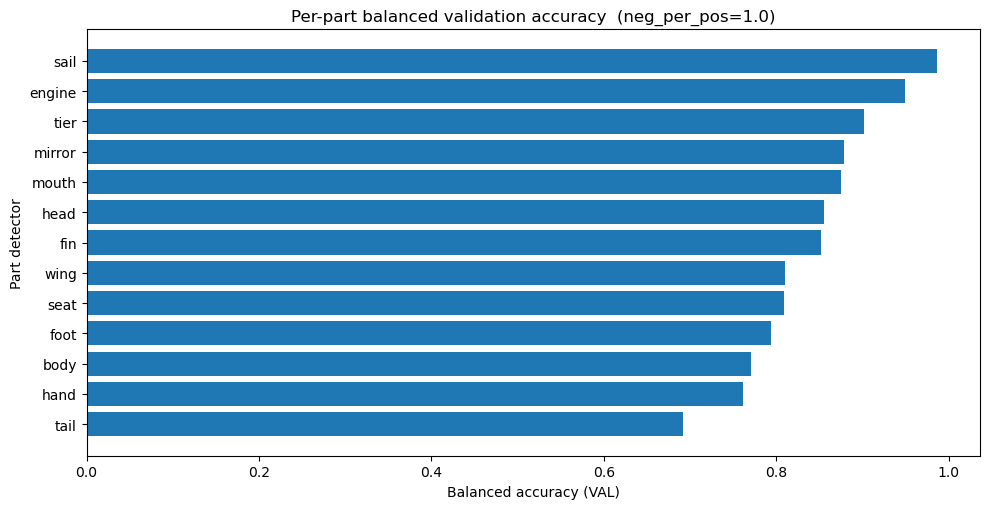

In [17]:
# ===== Cell 4: plot per-part balanced accuracy (VAL) =====
parts = [d["part"] for d in per_part_metrics]
accs  = [d["acc"]  for d in per_part_metrics]

order = np.argsort(accs)[::-1]   # highest first
parts_sorted = [parts[i] for i in order]
accs_sorted  = [accs[i]  for i in order]

plt.figure(figsize=(10, max(4, 0.4*len(parts_sorted))))
plt.barh(parts_sorted, accs_sorted)
plt.gca().invert_yaxis()
plt.xlabel("Balanced accuracy (VAL)")
plt.ylabel("Part detector")
plt.title(f"Per-part balanced validation accuracy  (neg_per_pos={neg_per_pos})")
plt.tight_layout()
plt.show()


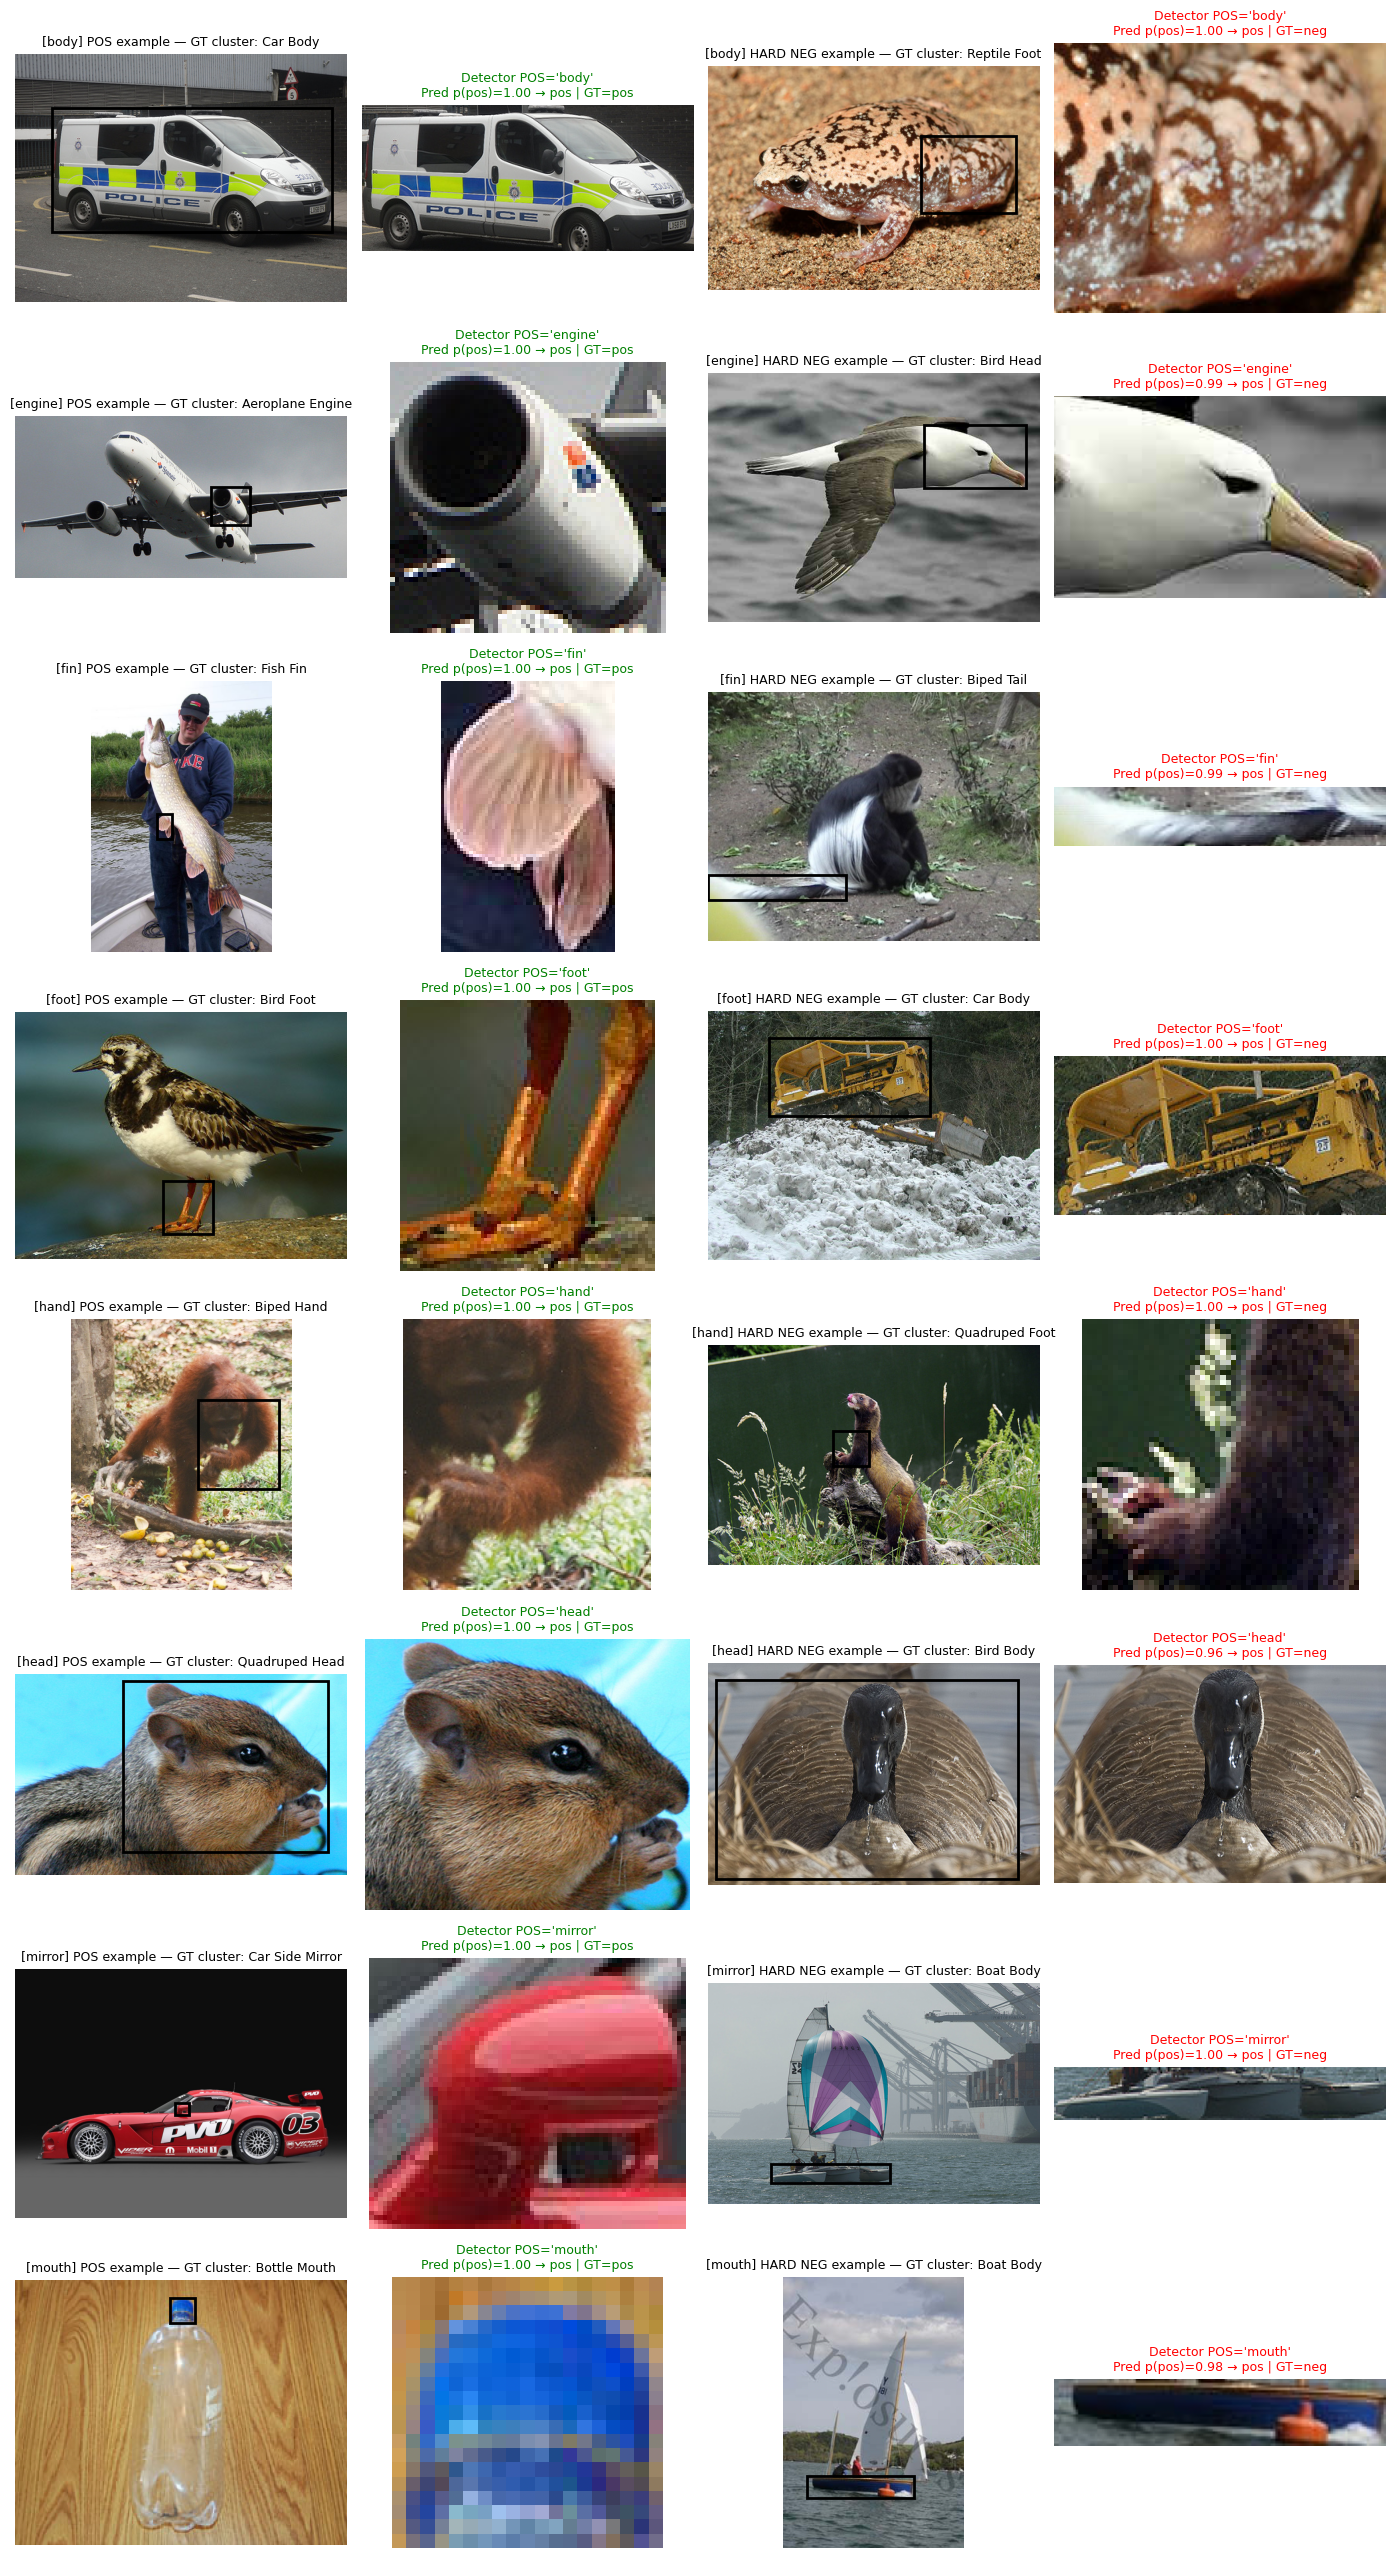

In [18]:
# ===== Cell 5: overall visualization across detectors =====

def _ann_to_xyxy(ann, W, H):
    # derive (x0,y0,x1,y1) from bbox; fall back to None if invalid
    bx = ann.get("bbox", None) if isinstance(ann, dict) else None
    if bx is None or len(bx) != 4:
        return None
    x, y, w, h = map(float, bx)
    x0, y0 = max(0, x), max(0, y)
    x1, y1 = min(W, x + max(0, w)), min(H, y + max(0, h))
    if x1 <= x0 or y1 <= y0:
        return None
    return int(x0), int(y0), int(x1), int(y1)

@torch.no_grad()
def _score_indices(model, ds, idxs):
    """Return probabilities p(pos) for each index in idxs."""
    probs = []
    for i in range(0, len(idxs), 128):
        chunk = idxs[i:i+128]
        xb = torch.stack([ds[j][0] for j in chunk]).to(DEVICE)
        pr = model(xb).softmax(1)[:, 1].detach().cpu().numpy()
        probs.extend(pr.tolist())
    return np.array(probs)

def visualize_overall(detectors: Dict[str, nn.Module], ds, max_parts: int = 8, seed: int = 0):
    rng = random.Random(seed)
    parts = sorted(detectors.keys())
    if max_parts is not None:
        parts = parts[:max_parts]

    # Precompute selections: one POS (highest p) and one HARD-NEG (highest p) for each part
    selections = []
    for part in parts:
        model = detectors[part]
        # indices
        pos_idxs = [i for i,it in enumerate(ds.items) if it.part_canonical == part]
        neg_idxs = [i for i,it in enumerate(ds.items) if it.part_canonical != part]
        if not pos_idxs or not neg_idxs:
            continue

        # score a small pool for speed
        pos_pool = rng.sample(pos_idxs, min(len(pos_idxs), 200))
        neg_pool = rng.sample(neg_idxs, min(len(neg_idxs), 200))
        pos_prob = _score_indices(model, ds, pos_pool)
        neg_prob = _score_indices(model, ds, neg_pool)

        pos_best = pos_pool[int(np.argmax(pos_prob))]
        neg_hard = neg_pool[int(np.argmax(neg_prob))]

        selections.append((part, pos_best, neg_hard))

    # Figure with rows = parts, columns = 4 (POS full, POS chip, NEG full, NEG chip)
    rows = len(selections); cols = 4
    plt.figure(figsize=(cols*3.5, rows*3.2))

    for r, (part, idx_pos, idx_neg) in enumerate(selections):
        for c, idx in enumerate([idx_pos, idx_pos, idx_neg, idx_neg]):
            x, det_idx, _, _ = ds[idx]
            it = ds.items[idx]
            img = Image.open(it.img_path).convert("RGB")
            chip = pil_crop_from_ann(img, it.bbox_or_seg_ann) or Image.new("RGB",(224,224),(0,0,0))
            # prediction
            p = float(detectors[part](x.unsqueeze(0).to(DEVICE)).softmax(1)[0,1].item())
            y_true = 1 if it.part_canonical == part else 0
            y_pred = 1 if p >= 0.5 else 0

            ax = plt.subplot(rows, cols, r*cols + c + 1)
            if c % 2 == 0:
                # full image with GT box
                ax.imshow(img); ax.axis('off')
                xy = _ann_to_xyxy(it.bbox_or_seg_ann, img.width, img.height)
                if xy:
                    x0,y0,x1,y1 = xy
                    ax.add_patch(plt.Rectangle((x0,y0), x1-x0, y1-y0, fill=False, linewidth=2))
                if c == 0:
                    ax.set_title(f"[{part}] POS example — GT cluster: {it.cluster_name}", fontsize=9)
                else:
                    ax.set_title(f"[{part}] HARD NEG example — GT cluster: {it.cluster_name}", fontsize=9)
            else:
                # chip with prediction
                ax.imshow(chip); ax.axis('off')
                ax.set_title(
                    f"Detector POS='{part}'\nPred p(pos)={p:.2f} → {'pos' if y_pred else 'neg'} | GT={'pos' if y_true else 'neg'}",
                    fontsize=9, color=("green" if y_pred==y_true else "red")
                )

    plt.tight_layout(); plt.show()

# Show up to 8 parts in one overview figure
visualize_overall(detectors, ds_val, max_parts=8, seed=42)


In [19]:
# ===== Per-detector performance table on VAL (balanced) =====
import os, math, random
from pathlib import Path
from typing import Dict, List
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

# ------------------------------------------------------------------
# 0) Environment / variables you already defined earlier
# ------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = "alex_binary_ckpts"  # your training code saved checkpoints here

# Ensure ds_val exists (same construction as in your earlier cells)
if 'ds_val' not in globals():
    ds_val = PartCropDataset2(
        ROOT, VAL_ANN, VAL_IMG_ROOT,
        transform=eval_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS
    )

# ------------------------------------------------------------------
# 1) Restore all per-part binary AlexNet detectors (same model you trained)
# ------------------------------------------------------------------
from part_detector_refactor import PartDetectorTiny  # used during training

class BinaryAlexNet(torch.nn.Module):
    def __init__(self, emb_dim: int = 128):
        super().__init__()
        self.net = PartDetectorTiny(
            emb_dim=emb_dim, num_classes=2,
            backbone="alexnet", backbone_trainable=False, weights=None
        )
    def forward(self, x):
        _, logits = self.net(x)  # logits: [B,2] -> (neg, pos)
        return logits

def load_detector(ckpt_path: str):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    part = str(ckpt.get("part", Path(ckpt_path).stem.replace("_best",""))).lower()
    emb  = int(ckpt.get("emb_dim", 128))
    m = BinaryAlexNet(emb_dim=emb).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"], strict=True)
    m.eval()
    return part, m, emb

detectors: Dict[str, torch.nn.Module] = {}
for p in sorted(Path(CKPT_DIR).glob("*_best.pt")):
    part_name, model, _ = load_detector(str(p))
    detectors[part_name] = model

if not detectors:
    raise RuntimeError(f"No *_best.pt checkpoints found in {CKPT_DIR}")

# ------------------------------------------------------------------
# 2) Balanced evaluation helpers (no DataLoader)
# ------------------------------------------------------------------
def _balanced_indices_for_part(ds, part_name: str, neg_per_pos: float = 1.0, seed: int = 1337):
    rng = random.Random(seed)
    pos = [i for i,it in enumerate(ds.items) if it.part_canonical == part_name]
    neg = [i for i,it in enumerate(ds.items) if it.part_canonical != part_name]
    n_pos = len(pos)
    n_neg_keep = min(len(neg), int(math.floor(n_pos * neg_per_pos)))
    neg = rng.sample(neg, n_neg_keep) if n_neg_keep > 0 else []
    idxs = pos + neg
    ys   = [1]*len(pos) + [0]*len(neg)
    order = list(range(len(idxs))); rng.shuffle(order)
    idxs = [idxs[k] for k in order]; ys = [ys[k] for k in order]
    return idxs, ys, n_pos, len(neg)

@torch.no_grad()
def _eval_detector_on_indices(model, ds, part_name: str, idxs: List[int], ys: List[int], batch_size: int = 128):
    part_idx = PART_TO_IDX[part_name]
    all_logits = []
    all_y      = []
    for i in range(0, len(idxs), batch_size):
        chunk = idxs[i:i+batch_size]
        xs, yb = [], []
        for j in chunk:
            x, det_idx, _, _ = ds[j]                # x already normalized by eval_tf
            y = 1 if det_idx == part_idx else 0
            xs.append(x); yb.append(y)
        xb = torch.stack(xs).to(DEVICE, non_blocking=True)
        yb = torch.tensor(yb, dtype=torch.long, device=DEVICE)
        logits = model(xb)                          # [B,2] (neg,pos)
        all_logits.append(logits.cpu()); all_y.append(yb.cpu())

    logits = torch.cat(all_logits, 0).numpy()
    ytrue  = torch.cat(all_y, 0).numpy()
    ypred  = logits.argmax(1)

    tp = int(((ypred == 1) & (ytrue == 1)).sum())
    tn = int(((ypred == 0) & (ytrue == 0)).sum())
    fp = int(((ypred == 1) & (ytrue == 0)).sum())
    fn = int(((ypred == 0) & (ytrue == 1)).sum())

    acc  = float((ypred == ytrue).mean())
    prec = float(tp / (tp + fp + 1e-9))
    rec  = float(tp / (tp + fn + 1e-9))
    f1   = float(2*prec*rec / (prec+rec + 1e-9)) if (prec+rec)>0 else 0.0

    return dict(
        acc=acc, prec=prec, rec=rec, f1=f1,
        tp=tp, tn=tn, fp=fp, fn=fn,
        n=len(ytrue)
    )

# ------------------------------------------------------------------
# 3) Evaluate every detector on a balanced slice of VAL and build a table
# ------------------------------------------------------------------
neg_per_pos = 1.0       # set 3.0 to mirror your training ratio if you used max_neg_per_pos=3.0
batch_size  = 128

rows = []
for part_name, model in sorted(detectors.items()):
    idxs, ys, n_pos, n_neg = _balanced_indices_for_part(ds_val, part_name, neg_per_pos=neg_per_pos, seed=1337)
    M = _eval_detector_on_indices(model, ds_val, part_name, idxs, ys, batch_size=batch_size)
    rows.append({
        "part": part_name,
        "n_eval": M["n"],
        "n_pos_eval": n_pos,
        "n_neg_eval": n_neg,
        "acc_bal_val": round(M["acc"], 4),
        "prec": round(M["prec"], 4),
        "rec": round(M["rec"], 4),
        "f1": round(M["f1"], 4),
        "tp": M["tp"], "tn": M["tn"], "fp": M["fp"], "fn": M["fn"],
        "neg_per_pos": neg_per_pos
    })

df_per_part = pd.DataFrame(rows).sort_values(["acc_bal_val","f1"], ascending=[False, False]).reset_index(drop=True)
display(df_per_part)

# Save for later analysis
out_csv = os.path.join(CKPT_DIR, "val_metrics_per_part_balanced.csv")
df_per_part.to_csv(out_csv, index=False)
print(f"Saved per-detector table to: {out_csv}")


,part,n_eval,n_pos_eval,n_neg_eval,acc_bal_val,prec,rec,f1,tp,tn,fp,fn,neg_per_pos
0,sail,78,39,39,0.9872,0.9750,1.0000,0.9873,39,38,1,0,1.0
1,engine,40,20,20,0.9500,0.9091,1.0000,0.9524,20,18,2,0,1.0
2,tier,642,321,321,0.9019,0.9300,0.8692,0.8986,279,300,21,42,1.0
3,mirror,148,74,74,0.8784,0.8889,0.8649,0.8767,64,66,8,10,1.0
4,mouth,40,20,20,0.8750,0.9412,0.8000,0.8649,16,19,1,4,1.0
5,head,2106,1053,1053,0.8552,0.9400,0.7588,0.8397,799,1002,51,254,1.0
6,fin,366,183,183,0.8525,0.9108,0.7814,0.8412,143,169,14,40,1.0
7,wing,190,95,95,0.8105,0.9041,0.6947,0.7857,66,88,7,29,1.0
8,seat,42,21,21,0.8095,0.8095,0.8095,0.8095,17,17,4,4,1.0
9,foot,2928,1464,1464,0.7941,0.8149,0.7609,0.7870,1114,1211,253,350,1.0


Saved per-detector table to: alex_binary_ckpts/val_metrics_per_part_balanced.csv


In [20]:
# ===== Cell 1: load all per-part binary AlexNet detectors =====
import os, json, math, random
from pathlib import Path
from typing import Dict, List, Tuple

import torch, torch.nn as nn, torch.nn.functional as F

from part_detector_refactor import PartDetectorTiny  # used during training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = "alex_binary_ckpts"   # your saved per-part models

class BinaryAlexNet(nn.Module):
    def __init__(self, emb_dim: int = 128):
        super().__init__()
        self.net = PartDetectorTiny(
            emb_dim=emb_dim, num_classes=2,
            backbone="alexnet", backbone_trainable=False, weights=None
        )
    def forward(self, x):
        # logits: [B,2] (neg, pos)
        _, logits = self.net(x)
        return logits
    def forward_with_emb(self, x):
        # returns (emb, logits) so fusion can use features
        return self.net(x)

def _load_detector(ckpt_path: str) -> Tuple[str, BinaryAlexNet, int]:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    part = str(ckpt.get("part", Path(ckpt_path).stem.replace("_best",""))).lower()
    emb  = int(ckpt.get("emb_dim", 128))
    m = BinaryAlexNet(emb_dim=emb).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"], strict=True)
    m.eval()
    return part, m, emb

# Build detectors dict if not already present
if 'detectors' not in globals():
    detectors: Dict[str, BinaryAlexNet] = {}
    emb_dims = set()
    for p in sorted(Path(CKPT_DIR).glob("*_best.pt")):
        part_name, model, emb_dim = _load_detector(str(p))
        detectors[part_name] = model
        emb_dims.add(emb_dim)
    print(f"Loaded {len(detectors)} detectors:", ", ".join(sorted(detectors.keys())))
else:
    print(f"[reuse] detectors already in memory: {len(detectors)}")

# In case embedding dims differ across parts, we’ll project inside the fusion module.


[reuse] detectors already in memory: 13


In [21]:
# ===== Cell 2: object (supercategory) label space + per-image index =====
import json

def _name_to_super_from_json(json_path: str) -> Dict[str, str]:
    with open(json_path, "r") as f:
        J = json.load(f)
    return {c["name"]: c.get("supercategory","Unknown") for c in J.get("categories", [])}

NAME_TO_SUPER = _name_to_super_from_json(os.path.join(ROOT, TRAIN_ANN))

def build_image_index(ds: 'PartCropDataset2'):
    """Return:
       - img_to_idxs: {image_id: [dataset indices belonging to that image]}
       - img_to_super: {image_id: supercategory string}, skipping ambiguous images
    """
    from collections import defaultdict, Counter
    img_to_idxs = defaultdict(list)
    img_to_supers = defaultdict(list)

    for idx, it in enumerate(ds.items):
        img_to_idxs[it.image_id].append(idx)
        # cluster_name is the original category name → map to supercategory
        sup = NAME_TO_SUPER.get(it.cluster_name, "Unknown")
        img_to_supers[it.image_id].append(sup)

    img_to_super = {}
    skipped_multi = 0
    for iid, sups in img_to_supers.items():
        cnt = Counter(sups)
        if len(cnt) == 1:
            img_to_super[iid] = next(iter(cnt.keys()))
        else:
            # ambiguous image with multiple object supers; skip for clean label
            skipped_multi += 1
    if skipped_multi:
        print(f"[image labeling] skipped {skipped_multi} images with mixed supercategories.")
    return img_to_idxs, img_to_super

# Ensure ds_train / ds_val exist (same construction as before); reuse if already built
if 'ds_tr' not in globals():
    ds_tr = PartCropDataset2(ROOT, TRAIN_ANN, TRAIN_IMG_ROOT, transform=eval_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
if 'ds_val' not in globals():
    ds_val = PartCropDataset2(ROOT, VAL_ANN,   VAL_IMG_ROOT,   transform=eval_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)

tr_img2idxs, tr_img2super = build_image_index(ds_tr)
vl_img2idxs, vl_img2super = build_image_index(ds_val)

OBJECT_CLASSES = sorted(set(tr_img2super.values()) | set(vl_img2super.values()))
OBJ_TO_IDX = {n:i for i,n in enumerate(OBJECT_CLASSES)}
print("Object classes:", OBJECT_CLASSES)


Object classes: ['Aeroplane', 'Bicycle', 'Biped', 'Bird', 'Boat', 'Bottle', 'Car', 'Fish', 'Quadruped', 'Reptile', 'Snake']


In [22]:
# ===== Cell 3: tokenization — per-image sequence of part tokens =====
import numpy as np
from typing import Optional

@torch.no_grad()
def _tokens_for_image(ds: 'PartCropDataset2',
                      img_indices: List[int],
                      detectors: Dict[str, BinaryAlexNet],
                      device=DEVICE) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Returns:
      emb_tokens: [K, E_proj_input]  (per-part aggregated embedding before projection)
      score_tokens: [K, 1]          (per-part scalar scores s_p = max_i p_pos)
    If an image has no chips (shouldn't happen), returns zeros.
    """
    # collect all chips for the image
    chips = []
    for j in img_indices:
        x, _, _, _ = ds[j]
        chips.append(x)
    if not chips:
        # fallback zero tokens
        K = len(detectors)
        return torch.zeros(K, 128), torch.zeros(K, 1)

    X = torch.stack(chips, 0).to(device, non_blocking=True)  # [N, 3, H, W]
    parts = sorted(detectors.keys())
    K = len(parts)

    emb_tokens = []
    score_tokens = []

    for p in parts:
        m = detectors[p]
        # forward all chips once for this detector (batch)
        emb, logits = m.forward_with_emb(X)     # emb: [N, emb_dim], logits: [N, 2]
        prob_pos = logits.softmax(1)[:, 1]      # [N]

        # per-part aggregation across chips:
        s_p = float(prob_pos.max().item())      # scalar score for "part present"
        w = prob_pos / (prob_pos.sum() + 1e-9)  # normalized weights for weighted average
        emb_avg = torch.einsum("n,ne->e", w, emb)  # [emb_dim]

        emb_tokens.append(emb_avg)
        score_tokens.append(torch.tensor([s_p], device=device))

    emb_tokens = torch.stack(emb_tokens, 0)               # [K, emb_dim]
    score_tokens = torch.stack(score_tokens, 0)           # [K, 1]
    return emb_tokens, score_tokens

@torch.no_grad()
def build_image_tokens_split(ds: 'PartCropDataset2',
                             img2idxs: Dict[int, List[int]],
                             img2super: Dict[int, str],
                             detectors: Dict[str, BinaryAlexNet],
                             max_images: Optional[int] = None,
                             device=DEVICE):
    parts = sorted(detectors.keys())
    img_ids = [iid for iid in img2idxs.keys() if iid in img2super]
    if max_images is not None:
        img_ids = img_ids[:max_images]

    X_emb, X_scr, Y = [], [], []
    kept = 0
    for iid in img_ids:
        emb_tok, scr_tok = _tokens_for_image(ds, img2idxs[iid], detectors, device=device)  # [K,E], [K,1]
        X_emb.append(emb_tok.cpu())
        X_scr.append(scr_tok.cpu())
        Y.append(OBJ_TO_IDX[img2super[iid]])
        kept += 1
        if kept % 100 == 0:
            print(f" tokenized {kept}/{len(img_ids)} images...")

    X_emb = torch.stack(X_emb, 0) if X_emb else torch.empty(0)
    X_scr = torch.stack(X_scr, 0) if X_scr else torch.empty(0)
    Y = torch.tensor(Y, dtype=torch.long)
    print(f"[tokenization] built {len(Y)} image-level samples, seq_len={len(parts)}")
    return X_emb, X_scr, Y, parts  # shapes: [N,K,E], [N,K,1], [N]


In [23]:
# ===== Cell 4: attention fusion for object classification =====
class AttentionFusion(nn.Module):
    """
    Inputs:
      - emb_tokens: [B, K, E]  (per-part aggregated embeddings)
      - score_tokens: [B, K, 1] (per-part scalar scores, e.g., max p(pos))
    Output:
      - logits_obj: [B, C] (object classes)
    """
    def __init__(self, K_parts: int, emb_dim_in: int, num_objects: int,
                 d_model: int = 128, nhead: int = 4, depth: int = 2, p_drop: float = 0.1):
        super().__init__()
        self.K = K_parts
        self.d_model = d_model
        self.num_objects = num_objects

        # Project per-part embeddings to d_model; concatenate the score => d_model + 1
        self.proj = nn.Linear(emb_dim_in, d_model)
        self.part_pos = nn.Parameter(torch.randn(K_parts, d_model))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=p_drop, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # small MLP head on CLS that also sees a global summary of part scores
        self.head = nn.Sequential(
            nn.LayerNorm(d_model + 1),
            nn.Linear(d_model + 1, d_model),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(d_model, num_objects)
        )

    def forward(self, emb_tokens: torch.Tensor, score_tokens: torch.Tensor):
        """
        emb_tokens: [B,K,E]; score_tokens: [B,K,1] in [0,1]
        """
        B, K, E = emb_tokens.shape
        z = self.proj(emb_tokens)                      # [B,K,d_model]
        # gate tokens by their presence scores (soft gating)
        z = z * score_tokens.clamp(0, 1)               # [B,K,d_model]
        # add part positional embeddings
        z = z + self.part_pos.unsqueeze(0)             # [B,K,d_model]
        # prepend CLS
        cls = self.cls_token.expand(B, 1, self.d_model)  # [B,1,d_model]
        z = torch.cat([cls, z], dim=1)                 # [B,K+1,d_model]
        z = self.encoder(z)                            # [B,K+1,d_model]
        cls_out = z[:, 0, :]                           # [B,d_model]

        # a simple global score summary (mean of part scores)
        s_global = score_tokens.mean(dim=1)            # [B,1]
        logits = self.head(torch.cat([cls_out, s_global], dim=1))  # [B,C]
        return logits


In [24]:
# --- Patch for per-part detectors missing forward_with_emb, plus robust tokenization ---
import types
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1) Add forward_with_emb to each detector, if missing.
#    For your PartDetectorTiny-based models, `self.net(x)` returns (emb, logits).
for name, m in detectors.items():
    if not hasattr(m, "forward_with_emb"):
        def _forward_with_emb(self, x):
            if hasattr(self, "net"):
                out = self.net(x)  # expected to return (emb, logits)
                if isinstance(out, tuple) and len(out) == 2:
                    return out
            # Fallback: only logits available -> fabricate a zero embedding of correct size if we can infer it.
            logits = self(x)
            emb_dim = 128
            try:
                # Try to infer emb_dim from your PartDetectorTiny structure
                if hasattr(self, "net") and hasattr(self.net, "emb") and isinstance(self.net.emb[0], nn.Linear):
                    emb_dim = int(self.net.emb[0].out_features)
            except Exception:
                pass
            z = torch.zeros((x.shape[0], emb_dim), device=logits.device, dtype=logits.dtype)
            return z, logits
        m.forward_with_emb = types.MethodType(_forward_with_emb, m)

# 2) Safe extractor used by tokenization (works for both patched and native models).
@torch.no_grad()
def _extract_emb_logits(model, x: torch.Tensor):
    if hasattr(model, "forward_with_emb"):
        out = model.forward_with_emb(x)
        if isinstance(out, tuple) and len(out) == 2:
            return out
    if hasattr(model, "net"):
        out = model.net(x)
        if isinstance(out, tuple) and len(out) == 2:
            return out
    # Last-resort fallback
    logits = model(x)
    emb_dim = 128
    try:
        if hasattr(model, "net") and hasattr(model.net, "emb") and isinstance(model.net.emb[0], nn.Linear):
            emb_dim = int(model.net.emb[0].out_features)
    except Exception:
        pass
    z = torch.zeros((x.shape[0], emb_dim), device=logits.device, dtype=logits.dtype)
    return z, logits

# 3) Re-define _tokens_for_image to use the robust extractor.
@torch.no_grad()
def _tokens_for_image(ds, img_indices, detectors, device=DEVICE):
    """
    Build per-image tokens:
      - emb_tokens: [K, E]   (per-part aggregated embeddings)
      - score_tokens: [K, 1] (per-part presence score s_p = max_i p_pos(i))
    """
    # Collect all chips in this image
    chips = []
    for j in img_indices:
        x, _, _, _ = ds[j]
        chips.append(x)
    if not chips:
        K = len(detectors)
        return torch.zeros(K, 128), torch.zeros(K, 1)

    X = torch.stack(chips, 0).to(device, non_blocking=True)  # [N, 3, H, W]
    parts = sorted(detectors.keys())
    K = len(parts)

    emb_tokens = []
    score_tokens = []

    for p in parts:
        m = detectors[p]
        z, logits = _extract_emb_logits(m, X)      # z: [N,E], logits: [N,2]
        prob_pos = logits.softmax(1)[:, 1]         # [N]
        s_p = float(prob_pos.max().item())         # scalar presence score
        w = prob_pos / (prob_pos.sum() + 1e-9)     # weights for weighted average
        emb_avg = torch.einsum("n,ne->e", w, z)    # [E]
        emb_tokens.append(emb_avg)
        score_tokens.append(torch.tensor([s_p], device=device))

    # NOTE: This assumes the detectors were trained with the same emb_dim.
    # If you intentionally used different emb_dim per part, unify dimensions here before stacking.
    emb_tokens = torch.stack(emb_tokens, 0)        # [K,E]
    score_tokens = torch.stack(score_tokens, 0)    # [K,1]
    return emb_tokens, score_tokens

# 4) Re-build tokens for train/val so you can continue with the fusion cell immediately
Xtr_emb, Xtr_scr, Ytr, parts = build_image_tokens_split(ds_tr, tr_img2idxs, tr_img2super, detectors, max_images=None, device=DEVICE)
Xvl_emb, Xvl_scr, Yvl, _     = build_image_tokens_split(ds_val, vl_img2idxs, vl_img2super, detectors, max_images=None, device=DEVICE)

print("Token shapes:")
print("  Train:", Xtr_emb.shape, Xtr_scr.shape, Ytr.shape)
print("  Val  :", Xvl_emb.shape, Xvl_scr.shape, Yvl.shape)


 tokenized 100/20452 images...
 tokenized 200/20452 images...
 tokenized 300/20452 images...
 tokenized 400/20452 images...
 tokenized 500/20452 images...
 tokenized 600/20452 images...
 tokenized 700/20452 images...
 tokenized 800/20452 images...
 tokenized 900/20452 images...
 tokenized 1000/20452 images...
 tokenized 1100/20452 images...
 tokenized 1200/20452 images...
 tokenized 1300/20452 images...
 tokenized 1400/20452 images...
 tokenized 1500/20452 images...
 tokenized 1600/20452 images...
 tokenized 1700/20452 images...
 tokenized 1800/20452 images...
 tokenized 1900/20452 images...
 tokenized 2000/20452 images...
 tokenized 2100/20452 images...
 tokenized 2200/20452 images...
 tokenized 2300/20452 images...
 tokenized 2400/20452 images...
 tokenized 2500/20452 images...
 tokenized 2600/20452 images...
 tokenized 2700/20452 images...
 tokenized 2800/20452 images...
 tokenized 2900/20452 images...
 tokenized 3000/20452 images...
 tokenized 3100/20452 images...
 tokenized 3200/2

In [25]:
# ===== Cell 5: train the attention fusion on train images, eval on val images =====
torch.cuda.empty_cache()

if Xtr_emb.numel() == 0 or Xvl_emb.numel() == 0:
    raise RuntimeError("No image-level samples were built. Check that your images have a unique supercategory each.")

# 2) Figure out the input emb_dim (may vary across parts; we projected inside the fusion)
emb_dim_in = Xtr_emb.shape[-1]
K_parts    = Xtr_emb.shape[1]
num_objects = len(OBJECT_CLASSES)

# 3) Build fusion model
fusion = AttentionFusion(
    K_parts=K_parts, emb_dim_in=emb_dim_in, num_objects=num_objects,
    d_model=128, nhead=4, depth=2, p_drop=0.1
).to(DEVICE)

opt = torch.optim.AdamW(fusion.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
crit = nn.CrossEntropyLoss()

def _batches(N, bs=64):
    for i in range(0, N, bs):
        yield slice(i, min(N, i+bs))

def _eval_split(XE, XS, Y, model: AttentionFusion):
    model.eval()
    tot_loss = 0.0; correct = 0; N = Y.shape[0]
    with torch.no_grad():
        for sl in _batches(N, bs=128):
            logits = model(XE[sl].to(DEVICE), XS[sl].to(DEVICE))
            loss = crit(logits, Y[sl].to(DEVICE))
            tot_loss += float(loss.item()) * (sl.stop - sl.start)
            correct  += int((logits.argmax(1).cpu() == Y[sl]).sum())
    return tot_loss / max(1,N), correct / max(1,N)

# 4) Train loop (small; tokens are already precomputed)
EPOCHS = 20
best = {"acc": -1, "state": None}
for ep in range(1, EPOCHS+1):
    fusion.train()
    N = Ytr.shape[0]
    perm = torch.randperm(N)
    XE, XS, Y = Xtr_emb[perm].to(DEVICE), Xtr_scr[perm].to(DEVICE), Ytr[perm].to(DEVICE)

    tr_loss = 0.0; tr_correct = 0
    for sl in _batches(N, bs=128):
        logits = fusion(XE[sl], XS[sl])
        loss = crit(logits, Y[sl])
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        tr_loss += float(loss.item()) * (sl.stop - sl.start)
        tr_correct += int((logits.argmax(1).detach().cpu() == Y[sl].detach().cpu()).sum())

    tr_loss = tr_loss / max(1,N)
    tr_acc  = tr_correct / max(1,N)
    vl_loss, vl_acc = _eval_split(Xvl_emb, Xvl_scr, Yvl, fusion)

    sched.step(vl_loss)
    if vl_acc > best["acc"]:
        best["acc"] = vl_acc
        best["state"] = {k: v.detach().cpu() for k,v in fusion.state_dict().items()}

    print(f"[fusion] ep {ep:02d}/{EPOCHS}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  "
          f"val_loss={vl_loss:.4f} val_acc={vl_acc:.3f}  best_val_acc={best['acc']:.3f}")

# restore best
if best["state"] is not None:
    fusion.load_state_dict(best["state"], strict=True)


/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[fusion] ep 01/20  tr_loss=1.0747 tr_acc=0.648  val_loss=0.9169 val_acc=0.708  best_val_acc=0.708
[fusion] ep 02/20  tr_loss=0.4940 tr_acc=0.833  val_loss=0.8681 val_acc=0.710  best_val_acc=0.710
[fusion] ep 03/20  tr_loss=0.4261 tr_acc=0.855  val_loss=0.8083 val_acc=0.736  best_val_acc=0.736
[fusion] ep 04/20  tr_loss=0.3929 tr_acc=0.862  val_loss=0.8462 val_acc=0.724  best_val_acc=0.736
[fusion] ep 05/20  tr_loss=0.3729 tr_acc=0.870  val_loss=0.7722 val_acc=0.744  best_val_acc=0.744
[fusion] ep 06/20  tr_loss=0.3577 tr_acc=0.876  val_loss=0.8201 val_acc=0.738  best_val_acc=0.744
[fusion] ep 07/20  tr_loss=0.3429 tr_acc=0.881  val_loss=0.7681 val_acc=0.756  best_val_acc=0.756
[fusion] ep 08/20  tr_loss=0.3286 tr_acc=0.884  val_loss=0.8002 val_acc=0.741  best_val_acc=0.756
[fusion] ep 09/20  tr_loss=0.3199 tr_acc=0.888  val_loss=0.7816 val_acc=0.757  best_val_acc=0.757
[fusion] ep 10/20  tr_loss=0.3079 tr_acc=0.891  val_loss=0.7777 val_acc=0.761  best_val_acc=0.761
[fusion] ep 11/20  t

[fusion] FINAL VAL object accuracy = 0.771 (loss=0.8158)


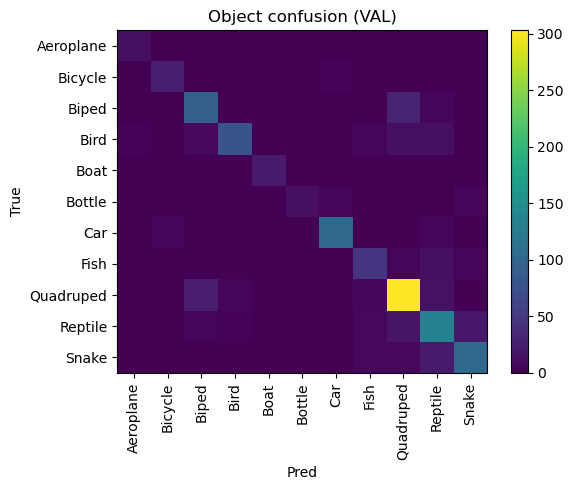

In [ ]:
# ===== Cell 6: final object classification on VAL =====
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

vl_loss, vl_acc = _eval_split(Xvl_emb, Xvl_scr, Yvl, fusion)
print(f"[fusion] FINAL VAL object accuracy = {vl_acc:.3f} (loss={vl_loss:.4f})")

# quick confusion (no seaborn; one chart)
with torch.no_grad():
    logits = []
    for sl in _batches(Yvl.shape[0], bs=128):
        logits.append(fusion(Xvl_emb[sl].to(DEVICE), Xvl_scr[sl].to(DEVICE)).cpu())
    logits = torch.cat(logits, 0)
    y_true = Yvl.numpy()
    y_pred = logits.argmax(1).numpy()

cm = np.zeros((num_objects, num_objects), dtype=np.int64)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plt.figure(figsize=(6, 5))
plt.imshow(cm, aspect='auto', interpolation='nearest')
plt.colorbar()
plt.xticks(range(num_objects), OBJECT_CLASSES, rotation=90)
plt.yticks(range(num_objects), OBJECT_CLASSES)
plt.xlabel("Pred")
plt.ylabel("True")
plt.title("Object confusion (VAL)")
plt.tight_layout()
plt.show()


In [ ]:
# --- Imports (safe if already imported elsewhere) ---
import os, json, re, math
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

# --- Reuse your existing components ---
assert 'ens'   in globals(), "Expected your part ensemble 'ens' to be defined."
assert 'fuser' in globals(), "Expected your attention fuser 'fuser' to be defined."
device = getattr(ens, "device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# Use your eval transform if defined, else Imagenet eval
VAL_TF = globals().get('eval_tf', transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
]))

# --- Pascal-Part-116 root (EDIT THIS ONLY if your tree is elsewhere) ---
PASCAL_ROOT = os.path.join("Datasets", "Pascal-Part-116")

IMG_DIR_VAL = os.path.join(PASCAL_ROOT, "images", "val")
PART_JSON_DIR_VAL = os.path.join(PASCAL_ROOT, "annotations_detectron2_part", "val")
OBJ_JSON_DIR_VAL  = os.path.join(PASCAL_ROOT, "annotations_detectron2_obj",  "val")

def _first_json(path):
    files = [f for f in os.listdir(path) if f.lower().endswith(".json")]
    if not files:
        raise FileNotFoundError(f"No .json found in {path}")
    return os.path.join(path, sorted(files)[0])

PART_JSON_VAL = _first_json(PART_JSON_DIR_VAL)
OBJ_JSON_VAL  = _first_json(OBJ_JSON_DIR_VAL)

print("[Pascal] val images at:", IMG_DIR_VAL)
print("[Pascal] parts json :", PART_JSON_VAL)
print("[Pascal] objects json:", OBJ_JSON_VAL)

with open(PART_JSON_VAL, "r") as f:
    pas_part = json.load(f)
with open(OBJ_JSON_VAL, "r") as f:
    pas_obj  = json.load(f)

print(f"[Pascal] part cats={len(pas_part['categories'])}, part anns={len(pas_part.get('annotations',[]))}, images={len(pas_part['images'])}")
print(f"[Pascal] obj cats={len(pas_obj['categories'])},  obj anns={len(pas_obj.get('annotations',[]))},  images={len(pas_obj['images'])}")
